# Decision Tree Concepts

## Table of Contents
  - [Introduction to Decision Trees](#introduction-to-decision-trees)
  - [Decision Tree Structure](#decision-tree-structure)
  - [Decision Trees for Classification](#decision-trees-for-classification)
      - [Splitting Criteria: Gini Impurity](#splitting-criteria-gini-impurity)
      - [Splitting Criteria: Information Gain & Entropy](#splitting-criteria-information-gain--entropy)
      - [Mathematical Formulations](#mathematical-formulations)
  - [Decision Trees for Regression](#decision-trees-for-regression)
      - [Variance Reduction & MSE](#variance-reduction--mse)
      - [Differences from Classification Trees](#differences-from-classification-trees)
  - [Hyperparameters & Regularization](#hyperparameters--regularization)
      - [Controlling Overfitting](#controlling-overfitting)
      - [Key Parameters](#key-parameters)
  - [Visualizing Decision Trees](#visualizing-decision-trees)
      - [Methods for Visualization](#methods-for-visualization)
      - [Interpreting Tree Visualizations](#interpreting-tree-visualizations)
  - [Advantages & Limitations](#advantages--limitations)
  - [Comparison with Previously Learned Models](#comparison-with-previously-learned-models)
  - [Appendix: Python Implementation Codes](#appendix-python-implementation-codes)

In [ ]:
# Import libraries we'll use throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris#, load_boston, load_diabetes
from sklearn.metrics import accuracy_score, mean_squared_error

## 1. Introduction to Decision Trees

Decision trees are versatile machine learning algorithms used for both classification and regression tasks. They're named "decision trees" because they mimic a flowchart-like structure where decisions branch out, eventually leading to predictions.

**Key Components**

A decision tree consists of the following components:

  * **Root Node:** The starting point of the tree. It represents the entire population or dataset and gets split into two or more homogeneous sets.
  * **Decision Nodes (Internal Nodes):** When a sub-node splits into further sub-nodes, it is called a decision node. This is where the "Question" is asked (e.g., "Is Age \> 30?").
  * **Branches:** The arrows connecting nodes, representing the outcome of a test (e.g., "Yes" or "No").
  * **Leaf Nodes (Terminal Nodes):** Nodes that do not split. This is where the final prediction is made.

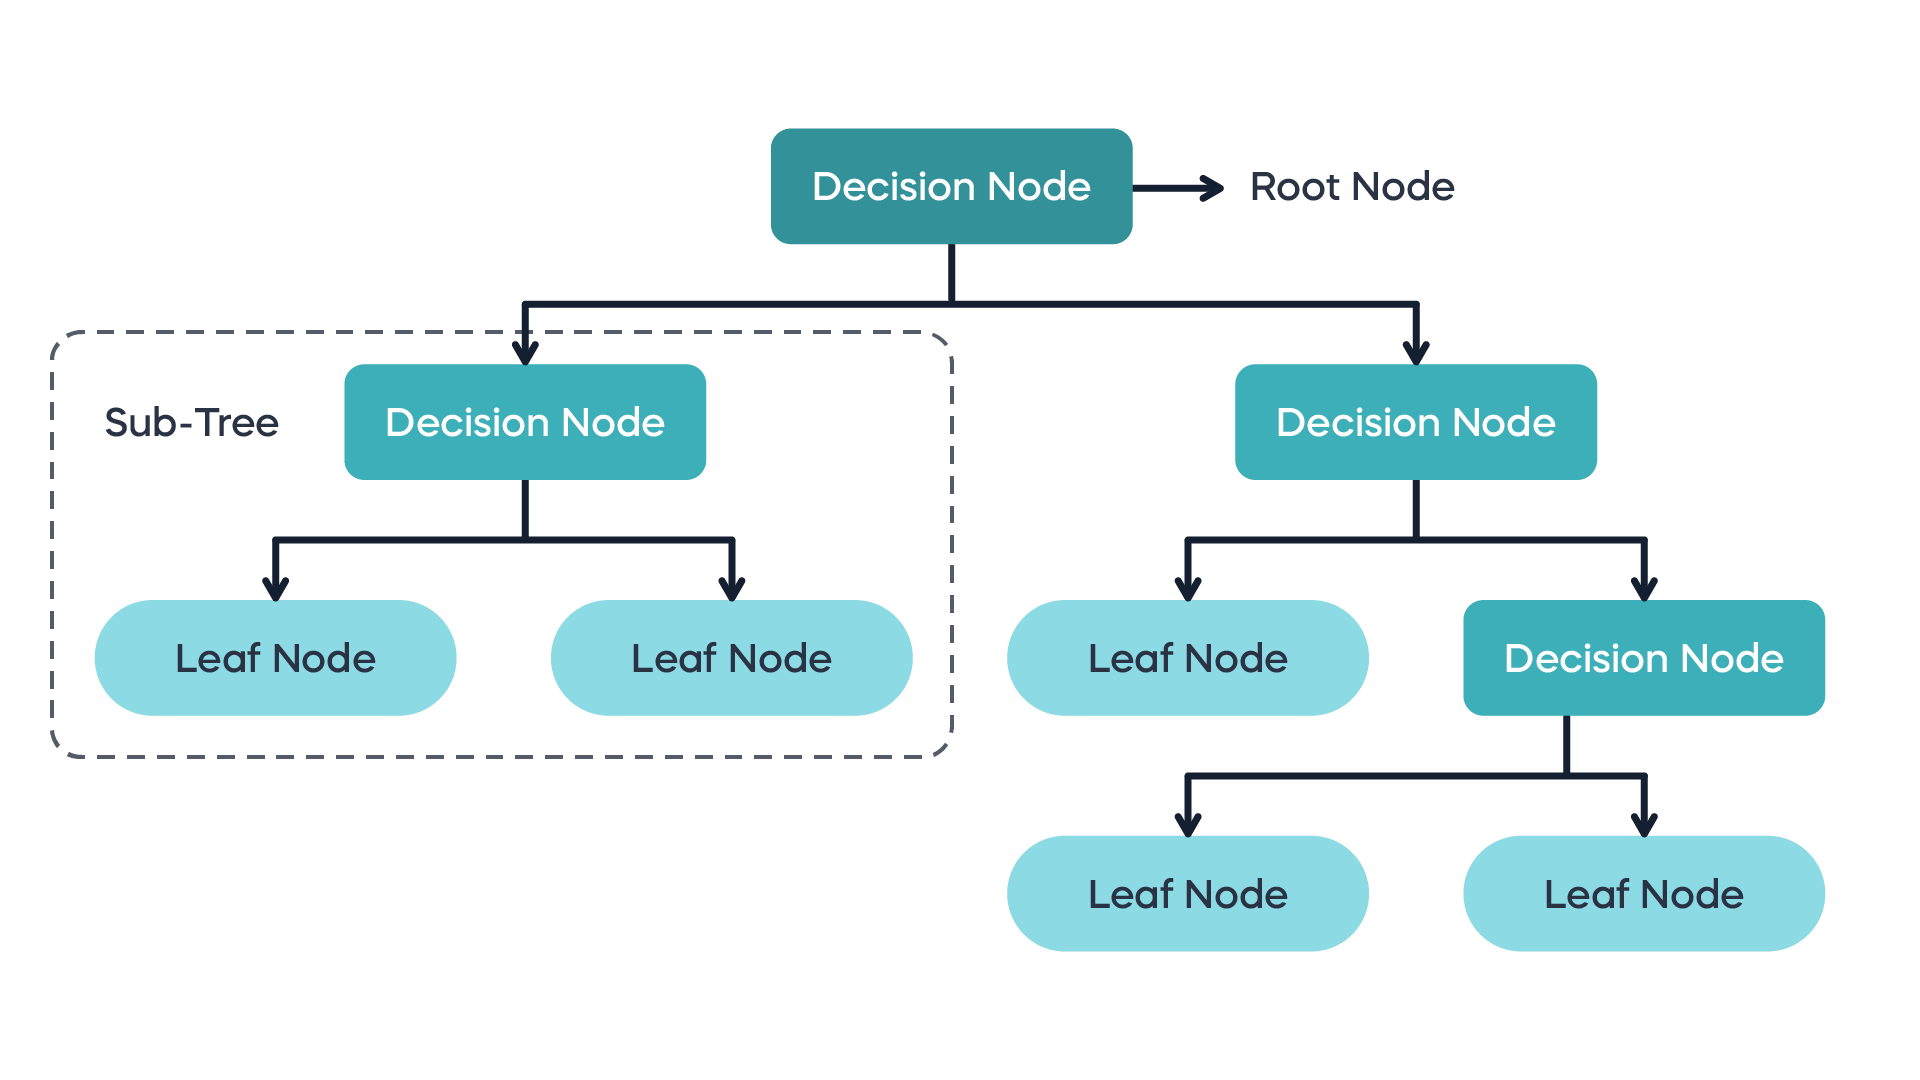

## 2\. The Core Mechanism: Recursive Partitioning

Decision trees use a **Greedy Approach** called **Recursive Binary Splitting**.

  * **"Greedy":** At each step, the algorithm makes the best possible split *at that exact moment* to maximize purity. It does not look ahead to see if a suboptimal split now might lead to a better split later.
  * **Recursive:** The process repeats for every child node until a stopping condition (like maximum depth) is met.

**The Golden Rule:** The goal of any split is to increase **Homogeneity**. We want the child nodes to be "purer" than the parent node.

Decision trees are built using a recursive partitioning process:
1. Start with the entire dataset at the root node
2. Select the best feature and split point that divides the data most effectively
3. Create child nodes based on the split
4. Recursively repeat for each child node until stopping criteria are met

### Knowledge Check: Decision Tree Structure

1. What are the four main components of a decision tree?
2. How is a decision tree similar to the game "20 Questions"?
3. What is the process by which decision trees are constructed?
4. Why might decision trees be preferable when model interpretation is important?

## 3\. Decision Trees for Classification (The "What")

When the target variable is categorical (e.g., "Spam" vs. "Not Spam"), we use Classification Trees. The algorithm must decide which feature to split on. To do this, it uses a metric to measure **Impurity** (chaos).

There are two primary metrics (splitting criteria) used: **Gini Impurity** and **Entropy**.

### A. Gini Impurity (The Standard)

Gini measures the probability that a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

  * **Formula:**
    $$\text{Gini} = 1 - \sum_{i=1}^{C} (p_i)^2$$
    Where $p_i$ is the proportion of samples belonging to class $i$ in that node and $c$ is the number of classes.
  * **Logic:**
      * If a node is "Pure" (all samples are Class A), $p_A = 1$. Then $\text{Gini} = 1 - 1^2 = 0$.
      * **Goal:** We want a Gini score as close to **0** as possible.

### B. Entropy & Information Gain

Entropy comes from information theory. It measures the randomness or disorder in the system.

  * **Entropy Formula:**
    $$\text{Entropy} = - \sum_{i=1}^{C} p_i \log_2(p_i)$$
  * **Information Gain:** This is the metric used to decide the split. It calculates the reduction in entropy after the dataset is split.
    $$\text{Information Gain} = \text{Entropy(parent)} - \sum \text{WeightedEntropy(children)}$$

**Decision Rule:** The algorithm calculates the Information Gain (or Gini decrease) for *every possible split* on *every feature* and chooses the one with the highest gain.

When selecting the best feature to split on, the algorithm evaluates all possible features and all possible split points, choosing the one that optimizes the criterion (minimizes impurity or maximizes information gain).

For each potential split:
1. Calculate the impurity measure (Gini or Entropy) for the parent node
2. Calculate the weighted impurity of the resulting child nodes
3. For Gini: Choose the split that minimizes weighted child impurity
4. For Entropy: Choose the split that maximizes information gain

In [55]:
# Let's demonstrate the calculation of Gini impurity and Entropy
def calculate_gini(class_distribution):
    """Calculate Gini impurity from a class distribution array"""
    proportions = class_distribution / np.sum(class_distribution)
    return 1 - np.sum(proportions**2)

def calculate_entropy(class_distribution):
    """Calculate entropy from a class distribution array"""
    proportions = class_distribution / np.sum(class_distribution)
    # Handle 0 proportions (log(0) is undefined)
    log_vals = np.log2(proportions, out=np.zeros_like(proportions), where=(proportions!=0))
    return -np.sum(proportions * log_vals)

In [56]:
# Example: Node with 10 samples of class A and 0 of class B (pure)
pure_node = np.array([10, 0])
print(f"Pure node - Gini impurity: {calculate_gini(pure_node):.4f}")
print(f"Pure node - Entropy: {calculate_entropy(pure_node):.4f}")

Pure node - Gini impurity: 0.0000
Pure node - Entropy: -0.0000


In [58]:
# Example: Node with 5 samples of class A and 5 of class B (impure)
impure_node = np.array([5, 5])
print(f"Impure node - Gini impurity: {calculate_gini(impure_node):.4f}")
print(f"Impure node - Entropy: {calculate_entropy(impure_node):.4f}")

Impure node - Gini impurity: 0.5000
Impure node - Entropy: 1.0000


In [59]:
# Example: Node with 7 samples of class A and 3 of class B (somewhat impure)
somewhat_impure = np.array([7, 3])
print(f"Somewhat impure node - Gini impurity: {calculate_gini(somewhat_impure):.4f}")
print(f"Somewhat impure node - Entropy: {calculate_entropy(somewhat_impure):.4f}")

Somewhat impure node - Gini impurity: 0.4200
Somewhat impure node - Entropy: 0.8813


In [60]:
# Example of Information Gain calculation
parent = np.array([5, 5])  # Parent node with 5 of each class
left_child = np.array([4, 1])  # Left child after split
right_child = np.array([1, 4])  # Right child after split

parent_entropy = calculate_entropy(parent)
left_weight = np.sum(left_child) / np.sum(parent)
right_weight = np.sum(right_child) / np.sum(parent)
weighted_child_entropy = left_weight * calculate_entropy(left_child) + right_weight * calculate_entropy(right_child)
information_gain = parent_entropy - weighted_child_entropy

print(f"\nParent entropy: {parent_entropy:.4f}")
print(f"Weighted child entropy: {weighted_child_entropy:.4f}")
print(f"Information Gain: {information_gain:.4f}")


Parent entropy: 1.0000
Weighted child entropy: 0.7219
Information Gain: 0.2781


In [ ]:
# Demonstration with Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [23]:
# Train trees with different criteria
gini_tree = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
entropy_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

gini_tree.fit(X_train, y_train)
entropy_tree.fit(X_train, y_train)

# Compare performance
y_pred_gini = gini_tree.predict(X_test)
y_pred_entropy = entropy_tree.predict(X_test)

print(f"Gini criterion accuracy: {accuracy_score(y_test, y_pred_gini):.4f}")
print(f"Entropy criterion accuracy: {accuracy_score(y_test, y_pred_entropy):.4f}")

Gini criterion accuracy: 1.0000
Entropy criterion accuracy: 1.0000


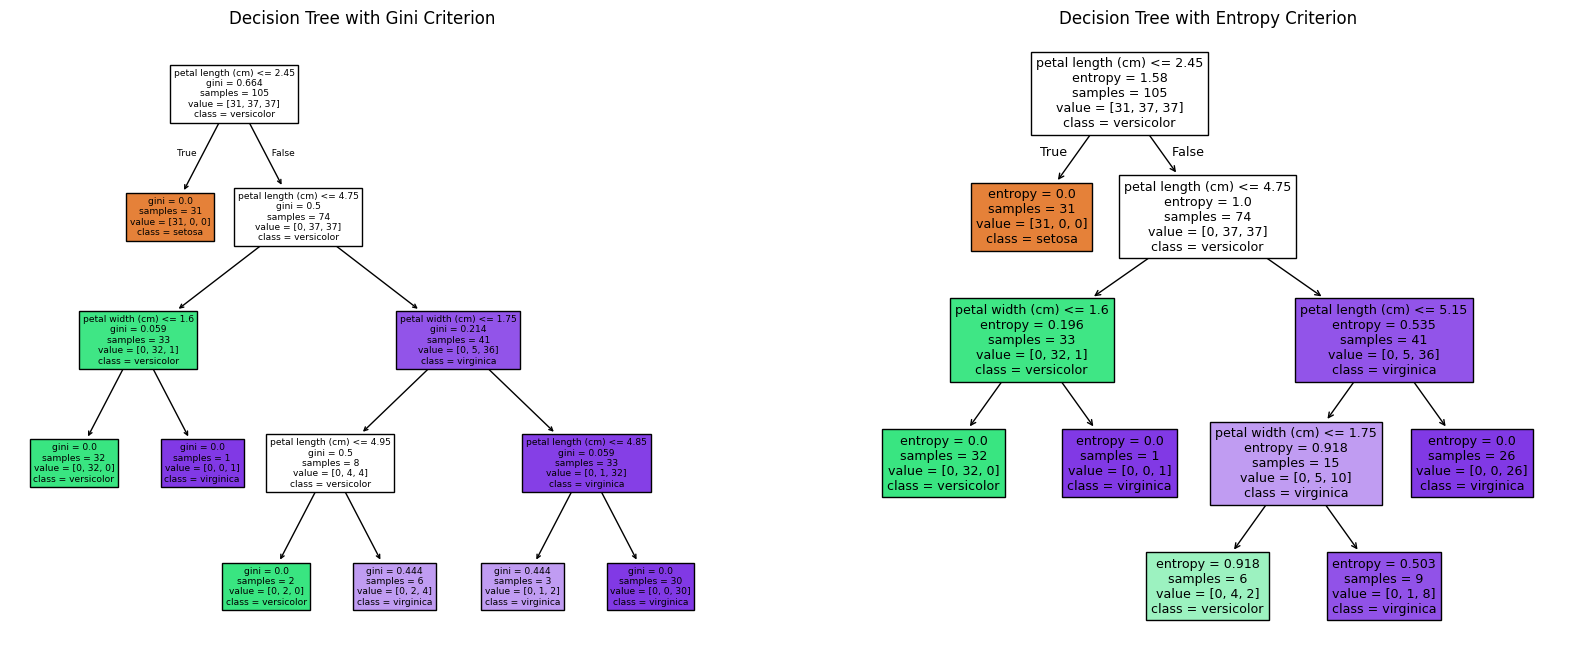

In [24]:
# Visualize both trees
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(gini_tree, filled=True, feature_names=iris.feature_names, 
          class_names=iris.target_names, ax=axes[0])
axes[0].set_title("Decision Tree with Gini Criterion")

plot_tree(entropy_tree, filled=True, feature_names=iris.feature_names, 
          class_names=iris.target_names, ax=axes[1])
axes[1].set_title("Decision Tree with Entropy Criterion")
plt.show()

### Knowledge Check: Decision Trees for Classification
1. What is Gini impurity and how is it calculated?
2. How does Entropy differ from Gini impurity as a splitting criterion?
3. Calculate the Gini impurity for a node with 8 samples of class A and 2 of class B.
4. What does it mean when a node has Gini impurity = 0 or Entropy = 0?
5. In practice, do Gini and Entropy criteria typically lead to very different trees?

## 4\. Decision Trees for Regression (The "How Much")


When the target variable is continuous (e.g., Price of a House), we use Regression Trees. The concept of "impurity" changes here because we don't have classes.

### A. Reduction in Variance (MSE)

Instead of Gini, regression trees typically use **Mean Squared Error (MSE)** or variance as the splitting criterion.

  * **Formula:**
    $$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y})^2$$
    Where $\hat{y}$ is the mean value of the target variable in that node.

### B. How the Split is Chosen

1.  The algorithm searches for a split point that results in the **lowest weighted MSE** for the child nodes.
2.  Basically, it tries to group similar values together so that the variance within each group is small.

### C. The Prediction

  * **Classification:** The prediction is the *majority class*.
  * **Regression:** The prediction is the **Mean (Average)** of all the samples that fell into that leaf.

In [40]:
# Example with a regression dataset
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a regression tree
regr_tree = DecisionTreeRegressor(max_depth=25, random_state=42)
regr_tree.fit(X_train, y_train)

# Evaluate performance
y_pred = regr_tree.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {np.sqrt(mse):.2f}")

Mean Squared Error: 5697.79
Root Mean Squared Error: 75.48


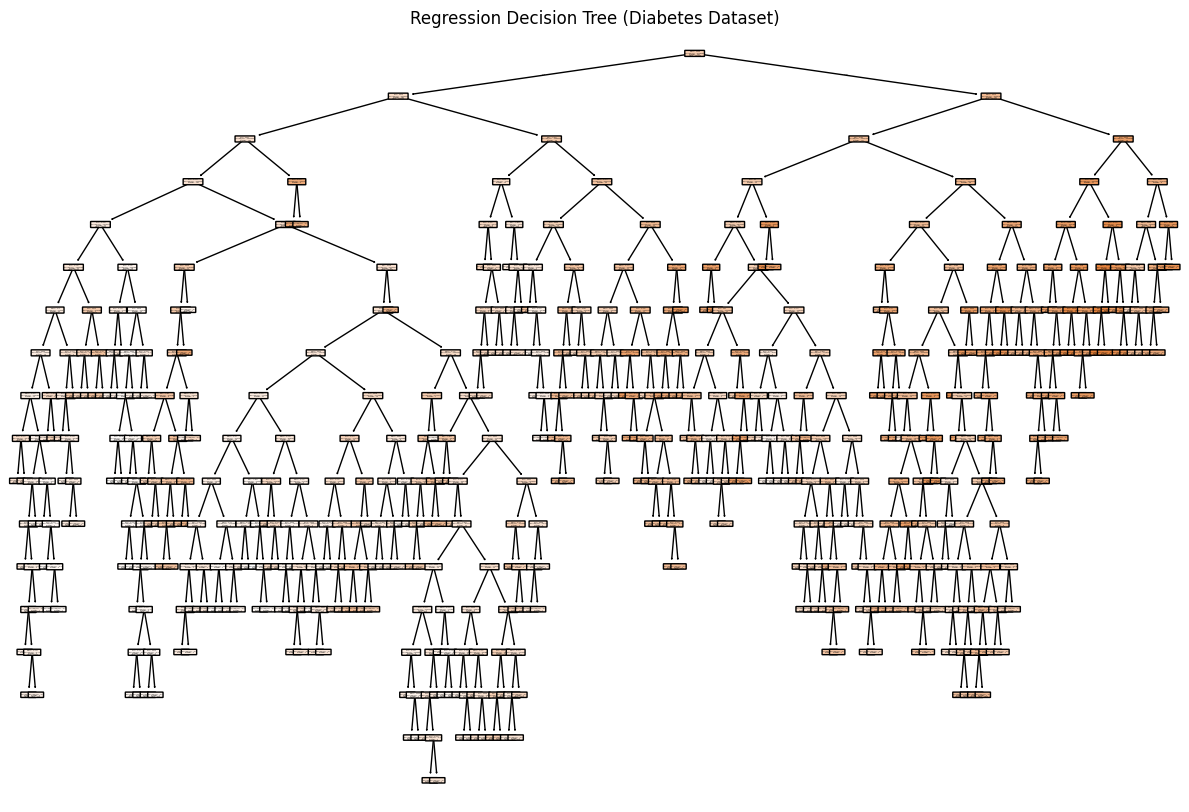

In [41]:
# Visualize the tree
plt.figure(figsize=(15, 10))
plot_tree(regr_tree, filled=True, feature_names=diabetes.feature_names, rounded=True)
plt.title("Regression Decision Tree (Diabetes Dataset)")
plt.show()

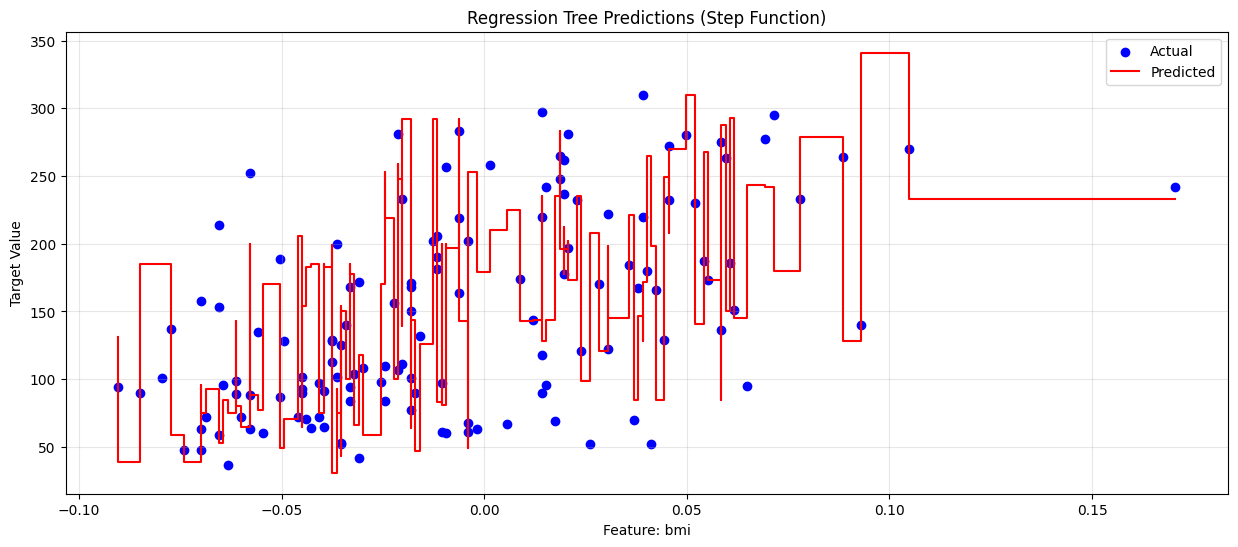

In [42]:
# Let's demonstrate how predictions work in a regression tree
# by plotting predictions vs actual for a single feature
if X.shape[1] > 0:  # Ensure there's at least one feature
    # Choose one feature for demonstration
    feature_idx = 2  # You can change this to any valid feature index
    
    # Sort the feature values for plotting
    sorted_idx = np.argsort(X_test[:, feature_idx])
    sorted_X = X_test[sorted_idx, feature_idx]
    sorted_y = y_test[sorted_idx]
    sorted_y_pred = y_pred[sorted_idx]
    
    plt.figure(figsize=(15, 6))
    plt.scatter(sorted_X, sorted_y, c='b', label='Actual')
    plt.step(sorted_X, sorted_y_pred, c='r', label='Predicted')
    plt.xlabel(f'Feature: {diabetes.feature_names[feature_idx]}')
    plt.ylabel('Target Value')
    plt.title('Regression Tree Predictions (Step Function)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

### Differences from Classification Trees

Key differences between regression and classification trees:

| Aspect | Classification Trees | Regression Trees |
|--------|----------------------|------------------|
| Prediction Type | Class label or probabilities | Continuous value |
| Splitting Criterion | Gini impurity or Entropy | Variance reduction or MSE |
| Leaf Node Output | Majority class or class distribution | Mean/median of target values |
| Prediction Pattern | Decision boundaries between classes | Piecewise constant function |

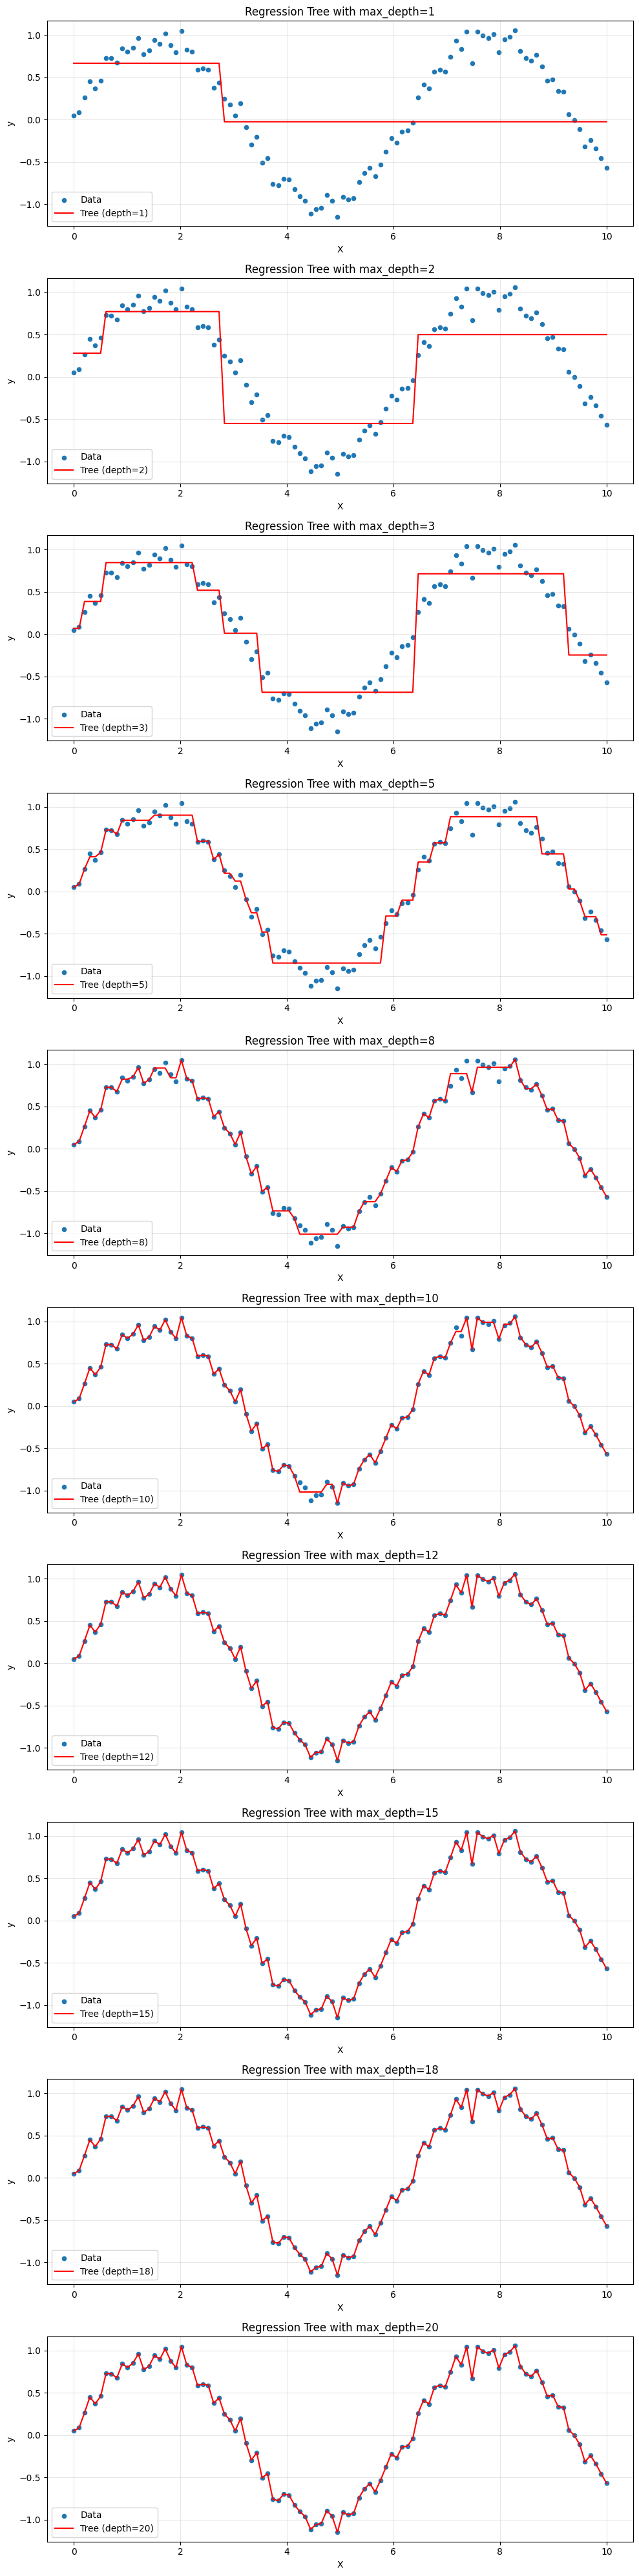

In [43]:
# Simple demonstration of the "step-like" predictions in regression trees
# Let's create a simple 1D regression problem
np.random.seed(42)
X_simple = np.linspace(0, 10, 100).reshape(-1, 1)
y_simple = np.sin(X_simple.ravel()) + np.random.normal(0, 0.1, 100)

# Fit regression trees of different depths
depths = [1, 2, 3, 5, 8, 10, 12, 15, 18, 20]
fig, axes = plt.subplots(len(depths), 1, figsize=(10, 4*len(depths)))

for i, depth in enumerate(depths):
    reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    reg_tree.fit(X_simple, y_simple)
    
    # Predict
    y_pred = reg_tree.predict(X_simple)
    
    # Plot
    axes[i].scatter(X_simple, y_simple, s=20, label='Data')
    axes[i].plot(X_simple, y_pred, color='r', label=f'Tree (depth={depth})')
    axes[i].set_title(f'Regression Tree with max_depth={depth}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('y')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Knowledge Check: Decision Trees for Regression
1. How do regression trees differ from classification trees in terms of what they predict?
2. What are the main splitting criteria used in regression trees?
3. Why do regression tree predictions often look "blocky" or like step functions?
4. Calculate the MSE for a node with target values [5, 6, 7, 8].
5. Would you expect a very deep regression tree to give smooth or jagged predictions? Why?

## 5\. Controlling the Tree: Hyperparameters



Decision trees are prone to **Overfitting**. Without constraints, a tree will keep splitting until every single leaf is pure (sometimes containing just one sample). This creates a model that memorizes the training data but fails on new data.

We control this using Hyperparameters (Pre-pruning):

| Hyperparameter | Description | Effect |
| :--- | :--- | :--- |
| **`max_depth`** | The maximum vertical depth of the tree. | **Low:** Underfitting (too simple). <br> **High:** Overfitting (too complex). |
| **`min_samples_split`** | The minimum number of samples required to split an internal node. | **High values** prevent the tree from creating splits for very small, specific groups (noise). |
| **`min_samples_leaf`** | The minimum number of samples required to be at a leaf node. | Guarantees that every final "decision" is based on at least $N$ samples, increasing stability. |
| **`max_features`** | The number of features to consider when looking for the best split. | Introducing randomness here can make the tree more robust (essential for Random Forests). |

```python
# 1. Split the data to check for Overfitting (Train vs Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Model A: Default Hyperparameters ---
tree_overfit = DecisionTreeClassifier(random_state=42) 
tree_overfit.fit(X_train, y_train)

# --- Model B: The Regularized Tree (Using Hyperparameters) ---
tree_regularized = DecisionTreeClassifier(
    max_depth=3,              # Limit vertical growth
    min_samples_leaf=10,      # Ensure leaves have enough data
    min_samples_split=20,     # Don't split small nodes
    random_state=42
)
tree_regularized.fit(X_train, y_train)

# --- Comparison ---
def evaluate_model(model, name):
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    depth = model.get_depth()
    leaves = model.get_n_leaves()
    
    print(f"--- {name} ---")
    print(f"Tree Depth: {depth}")
    print(f"Number of Leaves: {leaves}")
    print(f"Training Accuracy: {train_acc:.2f}")
    print(f"Test Accuracy:     {test_acc:.2f}")
    print(f"Gap (Overfitting): {train_acc - test_acc:.2f}\n")

evaluate_model(tree_overfit, "Default Tree")
evaluate_model(tree_regularized, "Regularized Tree")
````


## 6. Visualizing Decision Trees
One of the key advantages of decision trees is their interpretability through visualization.


### Methods for Visualization



There are several ways to visualize decision trees in scikit-learn:

1. **Text-based representation**:

In [46]:
# Text representation of a decision tree
iris = load_iris()
X = iris.data
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_clf.fit(X, y)

# Text visualization
tree_text = export_text(tree_clf, feature_names=iris.feature_names)
print("Text representation of the tree:")
print(tree_text)

Text representation of the tree:
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal width (cm) <= 1.75
|   |   |--- petal length (cm) <= 4.95
|   |   |   |--- petal width (cm) <= 1.65
|   |   |   |   |--- class: 1
|   |   |   |--- petal width (cm) >  1.65
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.95
|   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |--- class: 2
|   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |--- class: 2
|   |--- petal width (cm) >  1.75
|   |   |--- petal length (cm) <= 4.85
|   |   |   |--- sepal length (cm) <= 5.95
|   |   |   |   |--- class: 1
|   |   |   |--- sepal length (cm) >  5.95
|   |   |   |   |--- class: 2
|   |   |--- petal length (cm) >  4.85
|   |   |   |--- class: 2



2. **Matplotlib visualization with plot_tree**:

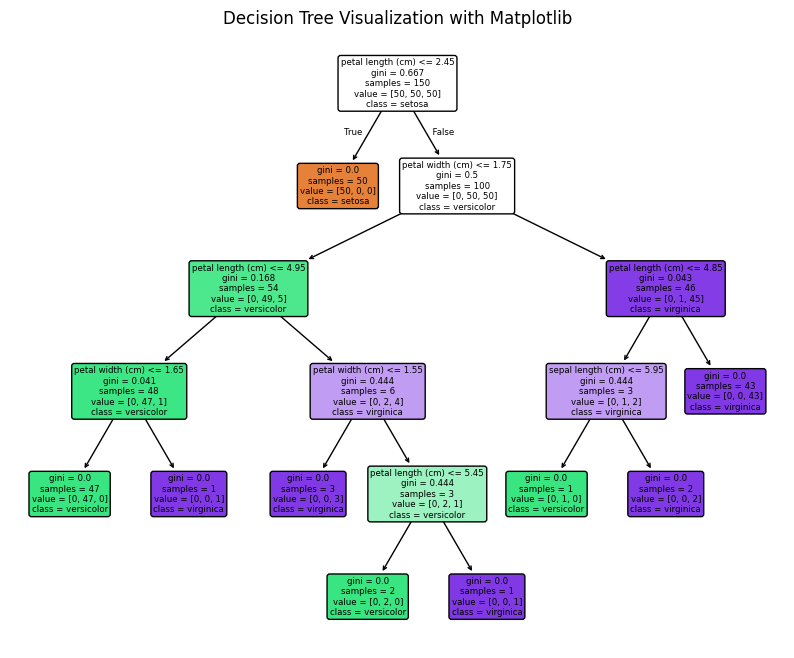

In [47]:
# Graphical visualization using matplotlib
plt.figure(figsize=(10, 8))
plot_tree(tree_clf, filled=True, feature_names=iris.feature_names, 
          class_names=iris.target_names, rounded=True)
plt.title("Decision Tree Visualization with Matplotlib")
plt.show()

### Interpreting Tree Visualizations

When examining a tree visualization, look for:

1. **The feature and threshold used for splitting at each node**
2. **The impurity measure (Gini/Entropy/MSE) at each node**
3. **The number of samples at each node**
4. **The class distribution (for classification) or predicted value (for regression)**
5. **The depth of the tree and complexity**

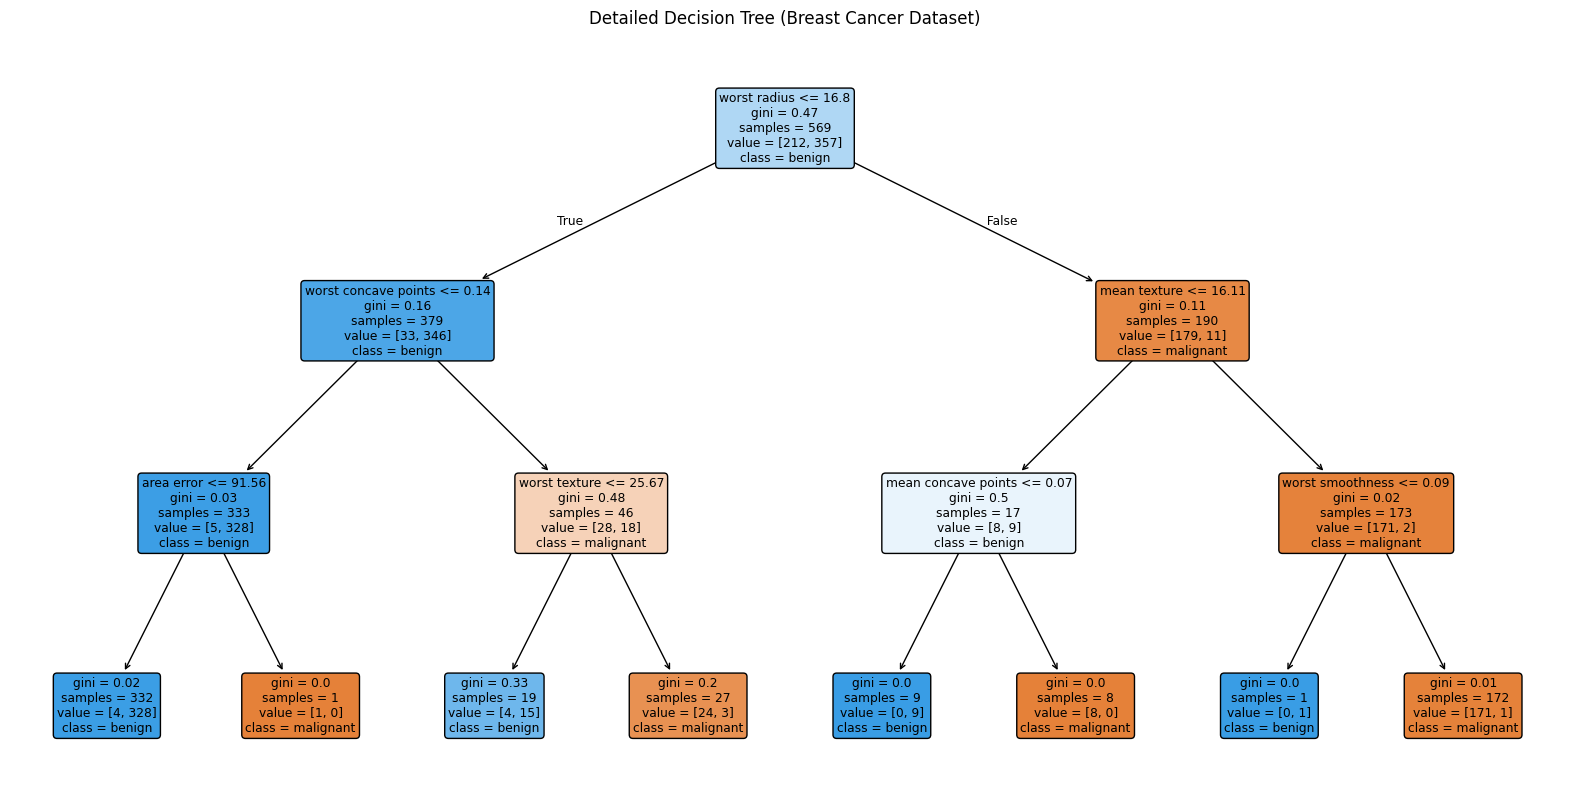

In [48]:
# Let's create a more detailed example to interpret
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

X_cancer = cancer.data
y_cancer = cancer.target

# Create and train a decision tree
cancer_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
cancer_tree.fit(X_cancer, y_cancer)

# Plot the tree with detailed node information
plt.figure(figsize=(20, 10))
plot_tree(cancer_tree, filled=True, feature_names=cancer.feature_names,
          class_names=['malignant', 'benign'], rounded=True, precision=2)
plt.title("Detailed Decision Tree (Breast Cancer Dataset)")
plt.show()

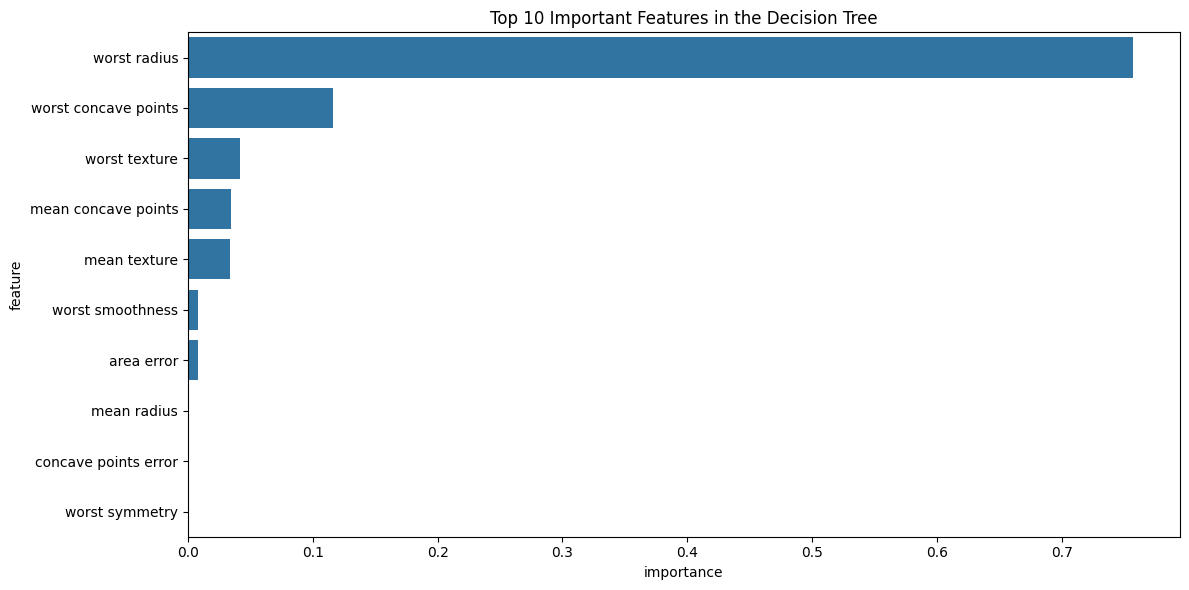

Top 5 most important features:
                 feature  importance
20          worst radius    0.756881
27  worst concave points    0.116533
21         worst texture    0.041982
7    mean concave points    0.034647
1           mean texture    0.033957


In [49]:
# Let's interpret the most important splits
feature_importance = cancer_tree.feature_importances_
features_df = pd.DataFrame({
    'feature': cancer.feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=features_df.head(10))
plt.title('Top 10 Important Features in the Decision Tree')
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(features_df.head(5))

### Knowledge Check: Visualizing Decision Trees
1. What information is typically displayed in a decision tree visualization?
2. Why might a text representation be useful for very large trees?
3. What can we learn from the feature importances derived from a decision tree?
4. How can you identify potential overfitting by examining a tree visualization?
5. When interpreting a node in a decision tree visualization, what do the different numbers typically represent?

## 7\. Advantages and Limitations



Every algorithm has a "sweet spot" and a breaking point. For Decision Trees, the trade-off is often between **interpretability** and **stability**.

### Advantages (Why we love them)

  * **Interpretability ("White Box" Model):**
      * This is the biggest selling point. You can visualize the tree and explain exactly *why* a prediction was made (e.g., "The loan was rejected because Income \< $50k").
  * **Minimal Data Preparation:**
      * **No Feature Scaling:** Trees don't care about the magnitude of values, only order. You don't need to Normalize or Standardize inputs.
      * **Robust to Outliers:** An extreme outlier affects only the local split, not the entire model.
  * **Non-Linearity:**
      * They can capture complex, non-linear relationships without needing complex feature engineering.

### Limitations (Where they fail)

  * **Overfitting (High Variance):**
      * If left uncontrolled, a decision tree will create a complex web of rules that perfectly fits the training data but fails on unseen data.
  * **Instability:**
      * A tiny change in the training data can result in a completely different tree structure. This is why **Random Forests** or **Gradient Boosting** are used more in production.
  * **Orthogonal Decision Boundaries:**
      * Trees cut data into rectangles. If the true relationship between two features is diagonal (e.g., $y = x$), a decision tree has to approximate this diagonal line with a "staircase" step function, which is inefficient.

## Comparison with Previously Learned Models

Let's compare decision trees with models we've previously covered like linear regression, logistic regression, and k-NN.

| Aspect | Decision Trees | Linear/Logistic Regression | k-NN |
|--------|---------------|----------------------------|------|
| Model Type | Non-parametric | Parametric | Non-parametric |
| Decision Boundary | Axis-parallel rectangles | Linear | Local, flexible |
| Interpretability | High | Medium (coefficients) | Low |
| Handling Non-linearity | Good | Poor (without transformations) | Good |
| Scaling Requirements | Not necessary | Important | Critical |
| Handling Categorical Data | Good | Requires encoding | Requires careful handling |
| Handling Missing Values | Extensions available | Requires imputation | Requires imputation |
| Computational Complexity | O(n_features * n_samples * log(n_samples)) | O(n_features * n_samples) | O(n_samples * n_features) for training, O(n * n_features) for prediction |
| Prone to Overfitting | Yes, significantly | Less so | Yes, with small k |

### When to Choose Decision Trees Over Other Models
- When interpretability is crucial
- When the data has non-linear relationships that are difficult to model with simple transformations
- When features are on very different scales and preprocessing is challenging
- When you need a baseline model before moving to more complex ensemble methods
- When handling mixed data types (numerical and categorical)

### Knowledge Check: Comparing Models
1. How do decision boundaries differ between decision trees and logistic regression?
2. In what scenarios would you prefer decision trees over linear models?
3. What advantage do linear models have over decision trees in terms of stability?
4. How do decision trees and k-NN differ in how they handle the feature space?
5. Which of the compared models would be most affected by feature scaling and why?

## Conclusion

In this notebook, we've explored the fundamental concepts of decision trees for both classification and regression tasks. We've learned:

- The structure and components of decision trees
- How trees make decisions using impurity measures like Gini and Entropy
- The differences between classification and regression trees
- Methods for visualizing and interpreting trees
- How decision trees compare to other machine learning models

In the next notebook (6.2), we'll explore the critical issue of overfitting in decision trees and techniques for complexity control to build more robust models.